<a href="https://colab.research.google.com/github/ojasvagr123/ml-lab/blob/main/Image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Imports and Installation**

In [ ]:
!pip install -q kagglehub gradio opencv-python-headless scikit-image joblib

In [ ]:
import os
import json
import random
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import joblib
import kagglehub
import gradio as gr
import tensorflow as tf

from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from skimage.feature import hog
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## **Dataset loading**

In [ ]:
DATASET_NAME = "shuvokumarbasak4004/world-flags-dataset-195"
path = kagglehub.dataset_download(DATASET_NAME)
print("Downloaded dataset path:", path)

ORIGINAL_DATASET_PATH = os.path.join(path, "data")
print("Original dataset folder:", ORIGINAL_DATASET_PATH)

all_classes = sorted([
    c for c in os.listdir(ORIGINAL_DATASET_PATH)
    if os.path.isdir(os.path.join(ORIGINAL_DATASET_PATH, c))
])

print("Total classes found:", len(all_classes))
print("First 10 classes:", all_classes[:10])

100%|██████████| 454M/454M [00:06<00:00, 78.3MB/s]

Extracting files...


Downloaded dataset path: /root/.cache/kagglehub/datasets/shuvokumarbasak4004/world-flags-dataset-195/versions/1
Original dataset folder: /root/.cache/kagglehub/datasets/shuvokumarbasak4004/world-flags-dataset-195/versions/1/data
Total classes found: 195
First 10 classes: ['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria']


In [ ]:
REDUCED_DATASET_PATH = "/content/flags_small"
IMAGES_PER_CLASS = 40   # keep this limited for faster and cleaner experiments

if os.path.exists(REDUCED_DATASET_PATH):
    shutil.rmtree(REDUCED_DATASET_PATH)

os.makedirs(REDUCED_DATASET_PATH, exist_ok=True)

for cls in all_classes:
    src_dir = os.path.join(ORIGINAL_DATASET_PATH, cls)
    dst_dir = os.path.join(REDUCED_DATASET_PATH, cls)
    os.makedirs(dst_dir, exist_ok=True)

    files = [f for f in os.listdir(src_dir) if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))]
    random.shuffle(files)
    selected_files = files[:IMAGES_PER_CLASS]

    for f in selected_files:
        shutil.copy(os.path.join(src_dir, f), os.path.join(dst_dir, f))

print("Reduced dataset created at:", REDUCED_DATASET_PATH)
print("Images per class used:", IMAGES_PER_CLASS)

Reduced dataset created at: /content/flags_small
Images per class used: 40


In [ ]:
records = []

for cls in sorted(os.listdir(REDUCED_DATASET_PATH)):
    cls_dir = os.path.join(REDUCED_DATASET_PATH, cls)
    if not os.path.isdir(cls_dir):
        continue

    for fname in os.listdir(cls_dir):
        fpath = os.path.join(cls_dir, fname)
        if fname.lower().endswith((".png", ".jpg", ".jpeg", ".webp")):
            records.append({"filepath": fpath, "label": cls})

df = pd.DataFrame(records)
print("Total images in reduced dataset:", len(df))
print(df.head())

Total images in reduced dataset: 7800
                                            filepath        label
0  /content/flags_small/Afghanistan/Afghanistan_8...  Afghanistan
1  /content/flags_small/Afghanistan/Afghanistan_1...  Afghanistan
2  /content/flags_small/Afghanistan/Afghanistan_9...  Afghanistan
3  /content/flags_small/Afghanistan/Afghanistan_3...  Afghanistan
4  /content/flags_small/Afghanistan/Afghanistan_2...  Afghanistan


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nTrain per class sample:")
print(train_df["label"].value_counts().head())

Train size: 6240
Validation size: 780
Test size: 780

Train per class sample:
label
Austria     32
Syria       32
Czechia     32
Ethiopia    32
Andorra     32
Name: count, dtype: int64


## **Image preprocessing**

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

class_names = sorted(train_df["label"].unique())
num_classes = len(class_names)

label_to_index = {label: idx for idx, label in enumerate(class_names)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

print("Number of classes:", num_classes)

Number of classes: 195


In [ ]:
def decode_and_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return img, tf.one_hot(label, depth=num_classes)

def build_tf_dataset(dataframe, training=False):
    paths = dataframe["filepath"].values
    labels = dataframe["label"].map(label_to_index).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED)

    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = build_tf_dataset(train_df, training=True)
val_ds = build_tf_dataset(val_df, training=False)
test_ds = build_tf_dataset(test_df, training=False)

print("TensorFlow datasets ready.")

TensorFlow datasets ready.


In [ ]:
def load_rgb_image(path, size=(128, 128)):
    img = cv2.imread(path)
    if img is None:
        print(f"Warning: Could not load image at path: {path}")
        return np.zeros((size[0], size[1], 3), dtype=np.uint8) # Return a black image placeholder
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    return img

def load_gray_image(path, size=(64, 64)):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Warning: Could not load image at path: {path}")
        return np.zeros(size, dtype=np.uint8) # Return a black image placeholder
    img = cv2.resize(img, size)
    return img

In [ ]:
HOG_SIZE = (64, 64)

def extract_hog_features(image_path):
    gray = load_gray_image(image_path, size=HOG_SIZE)

    feat = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        transform_sqrt=True
    )
    return feat

In [ ]:
def build_hog_matrix(dataframe):
    X = []
    y = []

    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        X.append(extract_hog_features(row["filepath"]))
        y.append(row["label"])

    X = np.array(X)
    y = np.array(y)
    return X, y

X_train_hog, y_train_hog = build_hog_matrix(train_df)
X_val_hog, y_val_hog = build_hog_matrix(val_df)
X_test_hog, y_test_hog = build_hog_matrix(test_df)

print("HOG train shape:", X_train_hog.shape)
print("HOG val shape:", X_val_hog.shape)
print("HOG test shape:", X_test_hog.shape)

  3%|▎         | 170/6240 [00:00<00:14, 414.21it/s]

  5%|▍         | 297/6240 [00:00<00:14, 412.82it/s]

  7%|▋         | 422/6240 [00:01<00:14, 395.23it/s]

  8%|▊         | 504/6240 [00:01<00:14, 396.44it/s]

  9%|▉         | 587/6240 [00:01<00:13, 404.80it/s]

...

 53%|█████▎    | 416/780 [00:01<00:00, 404.42it/s]

 75%|███████▍  | 582/780 [00:01<00:00, 409.00it/s]

 85%|████████▌ | 663/780 [00:01<00:00, 384.70it/s]

100%|██████████| 780/780 [00:01<00:00, 397.17it/s]

HOG train shape: (6240, 1764)
HOG val shape: (780, 1764)
HOG test shape: (780, 1764)


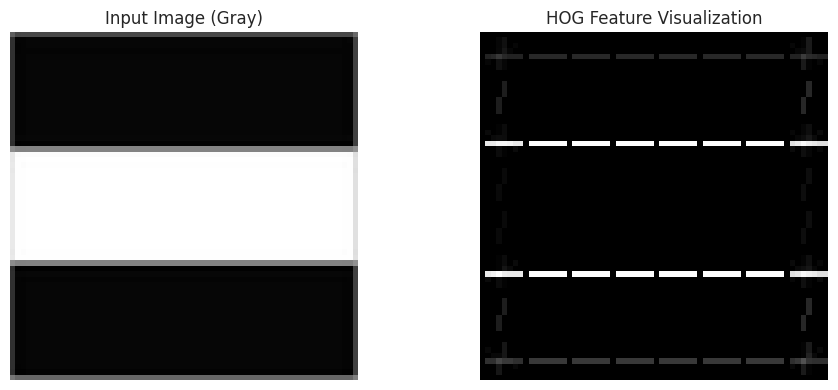

In [ ]:
sample_path = train_df.iloc[0]["filepath"]
sample_img = load_gray_image(sample_path, size=HOG_SIZE)

sample_hog, hog_vis = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    transform_sqrt=True,
    visualize=True
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_img, cmap="gray")
plt.title("Input Image (Gray)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_vis, cmap="gray")
plt.title("HOG Feature Visualization")
plt.axis("off")

plt.tight_layout()
plt.show()

## **EDA**

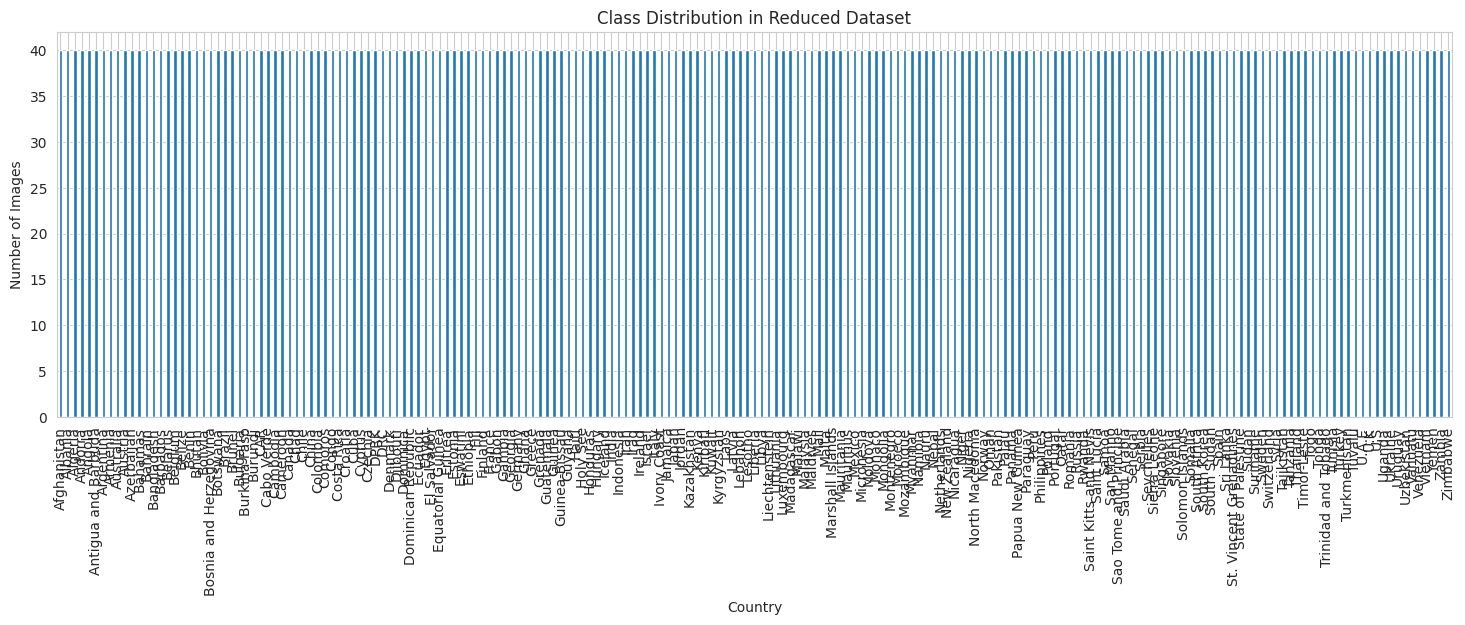

Unique classes: 195
Min images per class: 40
Max images per class: 40


In [ ]:
class_counts = df["label"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(18, 5))
class_counts.plot(kind="bar")
plt.title("Class Distribution in Reduced Dataset")
plt.xlabel("Country")
plt.ylabel("Number of Images")
plt.show()

print("Unique classes:", df['label'].nunique())
print("Min images per class:", class_counts.min())
print("Max images per class:", class_counts.max())

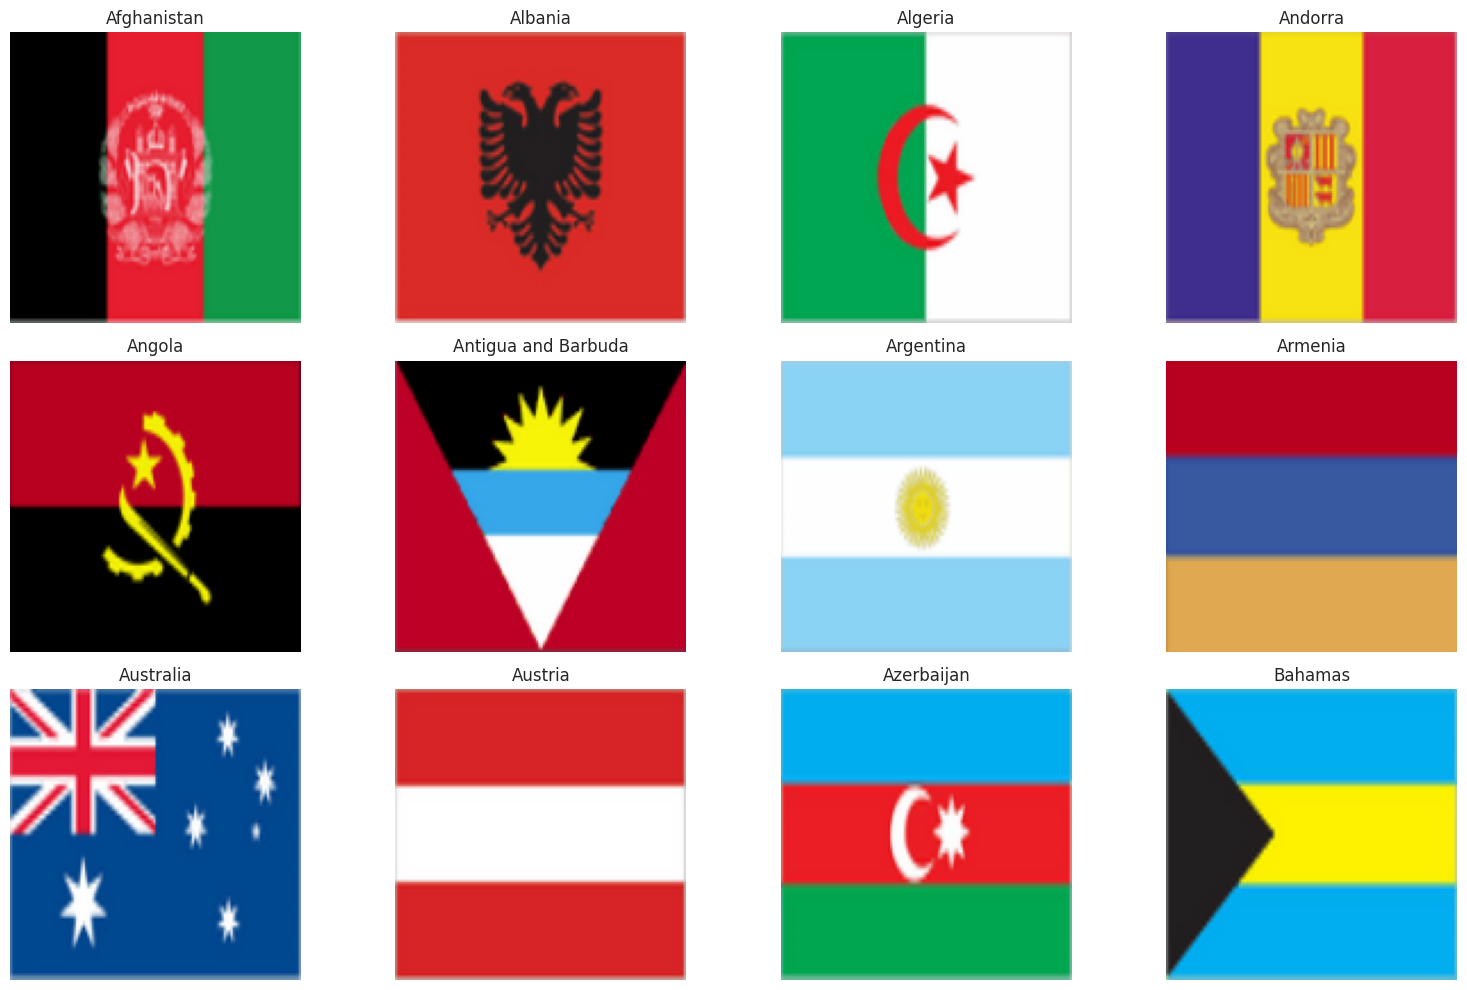

In [ ]:
plt.figure(figsize=(16, 10))

sample_classes = class_names[:12]

for i, cls in enumerate(sample_classes, 1):
    img_path = train_df[train_df["label"] == cls].iloc[0]["filepath"]
    img = load_rgb_image(img_path, size=(128, 128))

    plt.subplot(3, 4, i)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
image_shapes = []

for path in tqdm(df["filepath"].tolist()):
    img = cv2.imread(path)
    if img is None:
        print(f"Warning: Could not load image at path for shape analysis: {path}")
        continue # Skip this image if it couldn't be loaded
    h, w = img.shape[:2]
    image_shapes.append((h, w, h / w))

shape_df = pd.DataFrame(image_shapes, columns=["height", "width", "aspect_ratio"])
print(shape_df.describe())

 12%|█▏        | 947/7800 [00:00<00:03, 1831.43it/s]

 31%|███       | 2428/7800 [00:01<00:03, 1727.63it/s]

 42%|████▏     | 3282/7800 [00:01<00:03, 1496.15it/s]

100%|██████████| 7800/7800 [00:05<00:00, 1404.85it/s]

            height        width  aspect_ratio
count  7600.000000  7600.000000   7600.000000
mean     73.110526   118.836842      0.618767
std       9.003130     6.161379      0.100726
min      55.000000    61.000000      0.458333
25%      60.000000   120.000000      0.500000
50%      80.000000   120.000000      0.666667
75%      80.000000   120.000000      0.666667
max      90.000000   120.000000      1.311475


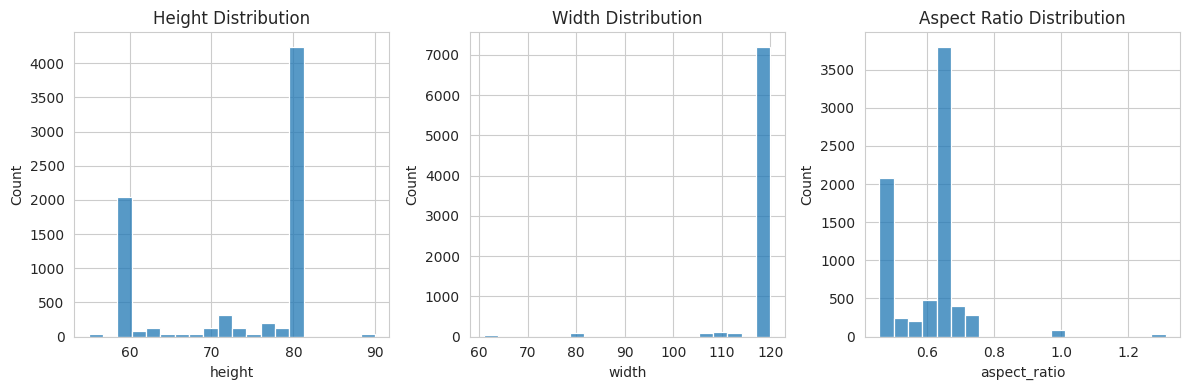

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(shape_df["height"], bins=20)
plt.title("Height Distribution")

plt.subplot(1, 3, 2)
sns.histplot(shape_df["width"], bins=20)
plt.title("Width Distribution")

plt.subplot(1, 3, 3)
sns.histplot(shape_df["aspect_ratio"], bins=20)
plt.title("Aspect Ratio Distribution")

plt.tight_layout()
plt.show()

## **Baseline model comparison**

In [ ]:
baseline_results = []

In [ ]:
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, n_jobs=-1))
])

logreg_pipeline.fit(X_train_hog, y_train_hog)
val_pred_logreg = logreg_pipeline.predict(X_val_hog)

acc = accuracy_score(y_val_hog, val_pred_logreg)
prec, rec, f1, _ = precision_recall_fscore_support(y_val_hog, val_pred_logreg, average="weighted", zero_division=0)

baseline_results.append({
    "Model": "HOG + Logistic Regression",
    "Val Accuracy": acc,
    "Val Precision": prec,
    "Val Recall": rec,
    "Val F1": f1
})

print("Logistic Regression validation accuracy:", acc)

Logistic Regression validation accuracy: 0.9794871794871794


In [ ]:
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

mobilenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()